# 05 - Country-Level Analysis

## Objective
- Analyze country-level IGO-cited paper proportions
- Evaluate country-level differences after stepwise adjustment (journal, IGO-cited refs, author's past)
- Examine relationship between author's past IGO-citation experience and IGO-cited probability
- Analyze journal-level IGO-cited proportions

## Inputs
- `tmp/policy_cited_paper.pickle`: IGO-cited paper data
- `tmp/partition_info.pickle`: Cluster information
- Scopus: year, authids, journal, afids, reference, num_cited, title, journal_name
- Scopus: af_country, IF_1972_2023_df

## Outputs
- `output/fig1_b_country_bias.eps`: Country-level IGO-cited ratio (stepwise adjustment)
- `output/fig1_c_journal_prop.eps`: Journal-level IGO-cited proportion
- `output/fig1_d_ref_influence.eps`: Relationship with IGO-cited reference count
- `output/fig1_e_author_influence.eps`: Relationship with author's past IGO-citation experience

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import collections
import matplotlib.pyplot as plt
import seaborn as sns
import pycountry
import warnings
import scienceplots
from matplotlib import colors
from adjustText import adjust_text

from config.settings import TmpPaths, OutputPaths, SCOPUS_BASE, POLICY_CITE_BASE

%matplotlib inline
%config InlineBackend.figure_format='retina'
plt.style.use(['science', 'no-latex'])
warnings.filterwarnings('ignore')

In [2]:

def flatten2(nested_list):
    return [item for sublist in nested_list if sublist == sublist for item in sublist]

def sum_from_tupple(tuples):
    result = {}
    for k, v in tuples:
        if k in result:
            result[k] += v
        else:
            result[k] = v
    return result

def classify_logarithmic_bins_base2(data):
    data = np.array(data) + 1
    min_val = max(data.min(), 1)
    max_val = data.max()
    min_exp = np.floor(np.log2(min_val))
    max_exp = np.ceil(np.log2(max_val))
    bins = 2 ** np.arange(min_exp, max_exp + 1)
    return np.digitize(data, bins, right=True)

In [3]:

policy_cited_scopus = pd.read_pickle(TmpPaths.POLICY_CITED_PAPER)
partition_info = pd.read_pickle(TmpPaths.PARTITION_INFO)
year_cited = pd.read_pickle(f'{POLICY_CITE_BASE}/year_cited.pickle')

for y in range(2017, 2025):
    policy_cited_scopus[f'year_cited_{y}'] = policy_cited_scopus.doi.map(year_cited[y])

print(f"Policy cited papers: {len(policy_cited_scopus):,}")

Policy cited papers: 230,737


In [4]:

papers = pd.concat([
    pd.read_pickle(f'{SCOPUS_BASE}/paper/year.pickle'),
    pd.read_pickle(f'{SCOPUS_BASE}/paper/authids.pickle'),
    pd.read_pickle(f'{SCOPUS_BASE}/paper/journal.pickle')
], axis=1).query('year >= 2015')

papers['ref'] = pd.read_pickle(f'{SCOPUS_BASE}/citation/reference.pickle')
papers['is_policy_cited'] = 0
papers.loc[policy_cited_scopus.index, 'is_policy_cited'] = 1

country_dict = pd.read_pickle(f'{SCOPUS_BASE}/affiliation/af_country.pickle').to_dict()
papers['afids'] = pd.read_pickle(f'{SCOPUS_BASE}/paper/afids.pickle')
papers['country_list'] = papers['afids'].dropna().apply(
    lambda x: [country_dict[y] for y in x if y in country_dict]
)

print(f"Papers (2015-): {len(papers):,}")
print(f"IGO-cited: {papers['is_policy_cited'].sum():,}")

Papers (2015-): 32,306,461
Policy-cited: 230,737


In [5]:

papers['country_list'] = papers['country_list'].apply(
    lambda x: [(y, 1/len(x)) for y in x] if isinstance(x, list) and len(x) > 0 else []
)

# Impact Factor
IF = pd.read_pickle(f'{SCOPUS_BASE}/journal/IF_1972_2023_df.pickle')
papers['IF'] = papers['journal'].map(IF[2020])
papers['policy_cited_cluster'] = policy_cited_scopus.partition

papers['cluster'] = pd.read_pickle(f'{SCOPUS_BASE}/clustering/leiden_CPM/partition_res_1e-07_margedto_6.pickle')
papers['title'] = pd.read_pickle(f'{SCOPUS_BASE}/paper/title.pickle')

In [6]:
TARGET_YEAR = 2020

pc = set(policy_cited_scopus.query(f'year_cited_{TARGET_YEAR-1} == 1').eid)
papers['reference_pc_len'] = papers['ref'].dropna().apply(lambda x: len(set(x) & pc))
papers['reference_pc_len'] = papers['reference_pc_len'].fillna(0)

print(f"IGO-cited papers before {TARGET_YEAR}: {len(pc):,}")

Policy-cited papers before 2020: 96,296


In [7]:

policy_cited_before_target = set(year_cited[year_cited[TARGET_YEAR-1] == 1].index)

cited_authors = pd.Series(collections.Counter(
    flatten2(policy_cited_scopus[
        policy_cited_scopus.doi.isin(policy_cited_before_target)
    ].query('year < @TARGET_YEAR').authids.apply(set))
))
cited_authors = dict(cited_authors)
cited_authors[0] = 0

papers['max_author_influence'] = papers.authids.apply(
    lambda x: np.max([0] + [cited_authors.get(y, 0) for y in set(x) if y in cited_authors])
)

papers['num_cited'] = pd.read_pickle(f'{SCOPUS_BASE}/paper/num_cited.pickle')

print(f"Authors with policy-citation experience: {len(cited_authors):,}")

Authors with policy-citation experience: 313,296


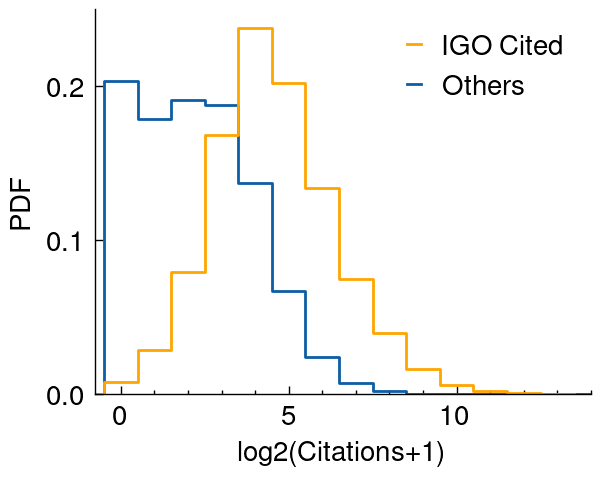

In [25]:

import matplotlib.pyplot as plt

plt.style.use(['science'])

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "axes.spines.right": False,
    "axes.spines.top": False,
})

plt.rcParams["text.latex.preamble"] = r"""
\usepackage{helvet}
\usepackage{sansmath}
\sansmath
\renewcommand{\familydefault}{\sfdefault}
"""



fig, ax = plt.subplots(1, 1, figsize=(3.2, 2.5))

# Others
vals = papers.query('year==2020 and is_policy_cited==0').num_cited.fillna(0).apply(lambda x: np.log2(x+1))
vals = pd.Series(collections.Counter(vals.apply(lambda x: int(x)-0.5)))
vals = vals / vals.sum()
vals.loc[-1] = 0

# Policy Cited
vals2 = papers.query('year==2020 and is_policy_cited==1').num_cited.fillna(0).apply(lambda x: np.log2(x+1))
vals2 = pd.Series(collections.Counter(vals2.apply(lambda x: int(x)-0.5)))
vals2 = vals2 / vals2.sum()
vals2.loc[-1] = 0

plt.step(vals.sort_index().index, vals.sort_index().values, label='Others', where='post')
plt.step(vals2.sort_index().index, vals2.sort_index().values, label='IGO Cited', where='post', c='orange')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=None, loc='upper right', handlelength=0.5)

plt.xlim([-0.6, 14])
plt.xlabel('log2(Citations+1)')
plt.ylabel('PDF')

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.yaxis.set_tick_params(which='minor', left=False)
ax.set_ylim([0, 0.25])
ax.set_xlim([-0.77, 14])
ax.set_yticks([0, 0.1, 0.2])

fig.savefig(f'../output/figures/figS1_citation_dist.eps')
fig.savefig(f'../output/figures/figS1_citation_dist.pdf')
plt.show()

---
# Country-Level Analysis (Figure 1-b)

In [9]:

papers['gr0'] = ''
papers['gr1'] = papers['gr0'] + papers['journal'].apply(int).apply(str)
papers['gr2'] = papers['gr1'] + papers['reference_pc_len'].fillna(0).apply(int).apply(str)
papers['gr3'] = papers['gr2'] + ' ' + papers['max_author_influence'].apply(int).apply(str)

In [10]:

country_paper = pd.Series(
    sum_from_tupple(flatten2(papers.sample(n=1000000, random_state=42).country_list))
).sort_values(ascending=False)

print(f"Top 50 countries: {list(country_paper.index[:50])}")

Top 50 countries: ['chn', 'usa', 'ind', 'gbr', 'deu', 'jpn', 'ita', 'rus', 'fra', 'can', 'kor', 'esp', 'aus', 'bra', 'irn', 'tur', 'pol', 'nld', 'idn', 'twn', 'che', 'mys', 'swe', 'bel', 'mex', 'prt', 'zaf', 'egy', 'cze', 'dnk', 'pak', 'sau', 'aut', 'isr', 'grc', 'nor', 'tha', 'ukr', 'sgp', 'fin', 'hkg', 'rou', 'arg', 'nzl', 'chl', 'irq', 'irl', 'col', 'nga', 'hun']


In [11]:

res = pd.DataFrame()

for gr in ['gr0', 'gr1', 'gr2', 'gr3']:
    papers_sample2 = papers.query('year == @TARGET_YEAR')[[gr, 'country_list', 'is_policy_cited']].copy()
    papers_sample2 = papers_sample2[papers_sample2.country_list.apply(len) > 0]
    
    g_all = papers_sample2.groupby([gr])
    g_is_cited = papers_sample2.query('is_policy_cited == 1').groupby([gr])
    
    count_country = pd.concat([
        pd.Series({k: sum_from_tupple(flatten2(v.country_list)) for k, v in g_all}),
        pd.Series({k: sum_from_tupple(flatten2(v.country_list)) for k, v in g_is_cited}),
        pd.Series({k: len(v) for k, v in g_all}),
        pd.Series({k: len(v) for k, v in g_is_cited}),
    ], axis=1)
    
    count_country.columns = ['country', 'country_policy_cited', 'num_paper', 'num_paper_policy_cited']
    count_country['expected_country_policy_cited'] = count_country.dropna().apply(
        lambda x: {k: v * x.num_paper_policy_cited / x.num_paper for k, v in x.country.items()}, axis=1
    )
    
    expected_total = pd.DataFrame(
        flatten2(count_country.expected_country_policy_cited.dropna().apply(lambda x: list(x.items())))
    ).groupby(0).sum()[1].sort_values(ascending=False)
    
    actual_total = pd.DataFrame(
        flatten2(count_country.country_policy_cited.dropna().apply(lambda x: list(x.items())))
    ).groupby(0).sum()[1].sort_values(ascending=False)
    
    tmp = pd.concat([actual_total, expected_total], axis=1).dropna()
    tmp.columns = ['act', 'est']
    tmp['per'] = tmp['act'] / tmp['est']
    tmp = tmp.sort_values('est').loc[country_paper[:50].index]
    tmp['gr'] = gr
    
    res = pd.concat([res, pd.DataFrame(tmp)])

print(f"Results shape: {res.shape}")

Results shape: (200, 4)


In [12]:

REGION_MAP = {
    'chn': 'Asia', 'usa': 'North America', 'ind': 'Asia', 'gbr': 'Europe', 'deu': 'Europe',
    'jpn': 'Asia', 'ita': 'Europe', 'rus': 'Europe', 'fra': 'Europe', 'kor': 'Asia',
    'rou': 'Europe', 'can': 'North America', 'aus': 'Oceania', 'ukr': 'Europe',
    'esp': 'Europe', 'bra': 'Latin America', 'irn': 'Asia', 'tur': 'Asia', 'pol': 'Europe',
    'nld': 'Europe', 'twn': 'Asia', 'nga': 'Africa', 'hun': 'Europe', 'che': 'Europe',
    'idn': 'Asia', 'swe': 'Europe', 'mys': 'Asia', 'bel': 'Europe', 'mex': 'Latin America',
    'arg': 'Latin America', 'chl': 'Latin America', 'col': 'Latin America', 'irq': 'Asia',
    'nzl': 'Oceania', 'irl': 'Europe', 'prt': 'Europe', 'dnk': 'Europe', 'zaf': 'Africa',
    'egy': 'Africa', 'isr': 'Asia', 'aut': 'Europe', 'cze': 'Europe', 'nor': 'Europe',
    'sau': 'Asia', 'grc': 'Europe', 'sgp': 'Asia', 'pak': 'Asia', 'fin': 'Europe',
    'hkg': 'Asia', 'tha': 'Asia'
}

res['Area'] = [REGION_MAP.get(i, 'Other') for i in res.index]
res['country'] = res.index
res.index = range(len(res))

country3_2 = {v.alpha_3.lower(): v.alpha_2 for v in list(pycountry.countries)}

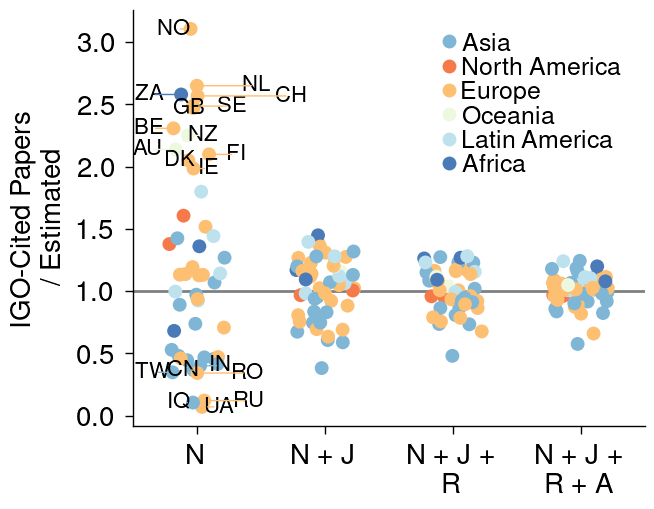

In [27]:
import matplotlib.pyplot as plt
plt.style.use(['science'])
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "axes.spines.right": False,
    "axes.spines.top": False,
})
plt.rcParams["text.latex.preamble"] = r"""
\usepackage{helvet}
\usepackage{sansmath}
\sansmath
\renewcommand{\familydefault}{\sfdefault}
"""
fig, ax = plt.subplots(1, 1, figsize=(3.3, 2.7))
colormap = [sns.color_palette('RdYlBu_r', n_colors=8)[i] for i in [1, 6, 5, 3, 2, 0]]
np.random.seed(2) 
sns.stripplot(data=res, x='gr', y='per', hue='Area', palette=colormap, alpha=1, ax=ax, jitter=0.23)
ax.legend(handletextpad=-0.5, labelspacing=0.05, fontsize=9).set_title('')

labels = [
    "N",
    "N +  J",
    "N + J + \n R",
    "N + J + \n R +  A"
]

indexes = []
indexes += list(res.query('gr=="gr0"').sort_values('per',ascending=False).index[[0,1,2,3,4,5,6,7,8,9,10,11,-7,-6,-5,-4,-3,-2,-1]])

coordinates = []
for collection in ax.collections[:1]:
    coordinates.extend(collection.get_offsets())

areas = res['Area'].unique()
area_to_color = dict(zip(areas, colormap))

texts = []
original_positions = []
text_colors = []

for i, (x, y) in enumerate(coordinates):
    y_value = res.iloc[i]['country']
    if res.index[i] in indexes:
        area = res.iloc[i]['Area']
        color = area_to_color[area]
        texts.append(ax.text(x, y, country3_2.get(y_value, y_value), ha='center', va='center', size=8, c='black'))
        original_positions.append((x, y))
        text_colors.append(color)


adjust_text(texts, force_text=(0.25, 0), only_move='x', min_arrow_len=10, arrowprops=None)

for text, (orig_x, orig_y), color in zip(texts, original_positions, text_colors):
    new_x, new_y = text.get_position()
    if abs(new_x - orig_x) > 0.05 or abs(new_y - orig_y) > 0.05:
        ax.annotate('', xy=(orig_x, orig_y), xytext=(new_x, new_y),
                    arrowprops=dict(arrowstyle='-', color=color, lw=0.5, alpha=1))

ax.set_xticks([0, 1, 2, 3])
ax.set_xlim([-0.5, 3.5])
ax.set_xticklabels(labels, rotation=0, ha='center', rotation_mode='anchor')
ax.minorticks_off()
ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('IGO-Cited Papers \n / Estimated')
ax.hlines(1, ax.get_xlim()[0], ax.get_xlim()[1], color='gray')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.tick_params(which='major', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', direction='out', left=False, bottom=False)
plt.savefig(f'../output/figures/fig1_b_country_bias.eps', bbox_inches='tight')
plt.savefig(f'../output/figures/fig1_b_country_bias.pdf', bbox_inches='tight')
plt.show()

---
# Author & Reference Influence Analysis (Figure 1-d, 1-e)

In [15]:

papers_ = papers.query('year == @TARGET_YEAR').copy()
papers_['title'] = pd.read_pickle(f'{SCOPUS_BASE}/paper/title.pickle')
papers_['journal_name'] = papers_['journal'].map(
    pd.read_pickle(f'{SCOPUS_BASE}/journal/journal_name.pickle')
)

# Logarithmic bins
papers_['max_author_influence_plot'] = classify_logarithmic_bins_base2(papers_.max_author_influence)
papers_['reference_pc_len_plot'] = classify_logarithmic_bins_base2(papers_.reference_pc_len)
papers_['reference_pc_len_plot'] = papers_['reference_pc_len_plot'].apply(lambda x: min([x, 6]))

print(f"Papers in {TARGET_YEAR}: {len(papers_):,}")

Papers in 2020: 3,766,262


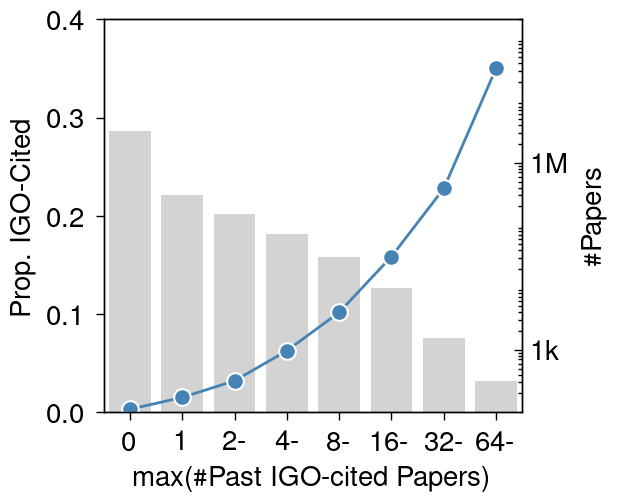


IGO-cited rate by author influence:
max_author_influence_plot
0    0.002889
1    0.014927
2    0.031919
3    0.062475
4    0.101629
5    0.158416
6    0.227799
7    0.350158
Name: is_policy_cited, dtype: float64


In [39]:
import matplotlib.pyplot as plt
plt.style.use(['science'])
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "axes.spines.right": True,
    "axes.spines.top": True,
})
plt.rcParams["text.latex.preamble"] = r"""
\usepackage{helvet}
\usepackage{sansmath}
\sansmath
\renewcommand{\familydefault}{\sfdefault}
"""
max_x = 8
fig, ax = plt.subplots(1, 1, figsize=(2.7, 2.55))
sns.lineplot(papers_, y='is_policy_cited', x='max_author_influence_plot',
            marker='o', ax=ax, color='#4583B5', ci=None, zorder=0)
ax.set_xticks(range(0, max_x))
ax.set_xticklabels([0, '1', '2-', '4-', '8-', '16-', '32-', '64-'])
ax.tick_params(axis='x', which='minor', bottom=False)
ax.tick_params(axis='x', which='minor', top=False)
ax.set_xlabel(r"max(\texttt{\#}Past IGO-cited Papers)")
ax.set_ylabel('Prop. IGO-Cited')
ax.set_ylim([0, 0.4])
df = papers_.groupby('max_author_influence_plot').count()[['year']]
ax2 = ax.twinx()
sns.barplot(x='max_author_influence_plot', y='year', data=df, ax=ax2, color='lightgray', zorder=1)
ax2.set_ylabel(r"\texttt{\#}Papers")
ax2.set_ylim([100, 200000000])
ax2.set_yscale('log')
ax2.set_yticks([1000, 1000000])
ax2.set_yticklabels(['1k', '1M'])
ax.set_zorder(ax2.get_zorder() + 1)
ax.set_ylim([0, 0.4])
ax.patch.set_visible(False)
ax.tick_params(which='major', direction='out', left=True, bottom=True, top=False)
ax.tick_params(which='minor', direction='out', left=False, right=False, bottom=False)
plt.savefig(f'../output/figures/fig1_e_author_influence.eps', bbox_inches='tight')
plt.savefig(f'../output/figures/fig1_e_author_influence.pdf', bbox_inches='tight')
plt.show()
print("\nIGO-cited rate by author influence:")
print(papers_.groupby('max_author_influence_plot').is_policy_cited.mean())


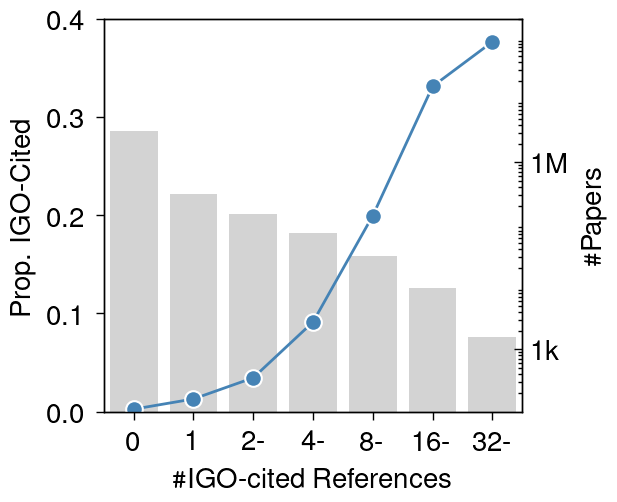


IGO-cited rate by author influence:
max_author_influence_plot
0    0.002889
1    0.014927
2    0.031919
3    0.062475
4    0.101629
5    0.158416
6    0.227799
7    0.350158
Name: is_policy_cited, dtype: float64


In [40]:


max_x = 7

fig, ax = plt.subplots(1, 1, figsize=(2.7, 2.55))
sns.lineplot(papers_, y='is_policy_cited', x='reference_pc_len_plot',
            marker='o', ax=ax, color='#4583B5', ci=None, zorder=0)
ax.set_xticks(range(0, max_x))
ax.set_xticklabels([0, '1', '2-', '4-', '8-', '16-', '32-'])
ax.tick_params(axis='x', which='minor', bottom=False)
ax.tick_params(axis='x', which='minor', top=False)
ax.set_xlabel(r"\texttt{\#}IGO-cited References")
ax.set_ylabel('Prop. IGO-Cited')
ax.set_ylim([0, 0.4])
df = papers_.groupby('max_author_influence_plot').count()[['year']]
ax2 = ax.twinx()
sns.barplot(x='max_author_influence_plot', y='year', data=df, ax=ax2, color='lightgray', zorder=1)
ax2.set_ylabel(r"\texttt{\#}Papers")
ax2.set_ylim([100, 200000000])
ax2.set_yscale('log')
ax2.set_yticks([1000, 1000000])
ax2.set_yticklabels(['1k', '1M'])
ax.set_zorder(ax2.get_zorder() + 1)
ax.set_ylim([0, 0.4])
ax.patch.set_visible(False)
ax.tick_params(which='major', direction='out', left=True, bottom=True, top=False)
ax.tick_params(which='minor', direction='out', left=False, right=False, bottom=False)
plt.savefig(f'../output/figures/fig1_d_ref_influence.eps', bbox_inches='tight')
plt.savefig(f'../output/figures/fig1_d_ref_influence.pdf', bbox_inches='tight')
plt.show()
print("\nIGO-cited rate by author influence:")
print(papers_.groupby('max_author_influence_plot').is_policy_cited.mean())




---
# Journal-Level Analysis (Figure 1-c)

In [30]:

journal = papers_.groupby('journal').count()['year'].to_frame()
journal.columns = ['num_paper']
journal['num_policy_cited_paper'] = policy_cited_scopus.query('year == @TARGET_YEAR').groupby('journal').count()['year']
journal['IF'] = IF[2020]
journal['name'] = pd.read_pickle(f'{SCOPUS_BASE}/journal/journal_name.pickle')
journal['num_policy_cited_paper'] = journal['num_policy_cited_paper'].fillna(0)
journal['per'] = journal['num_policy_cited_paper'] / journal['num_paper']

print(f"Total journals: {len(journal):,}")

Total journals: 47,309


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


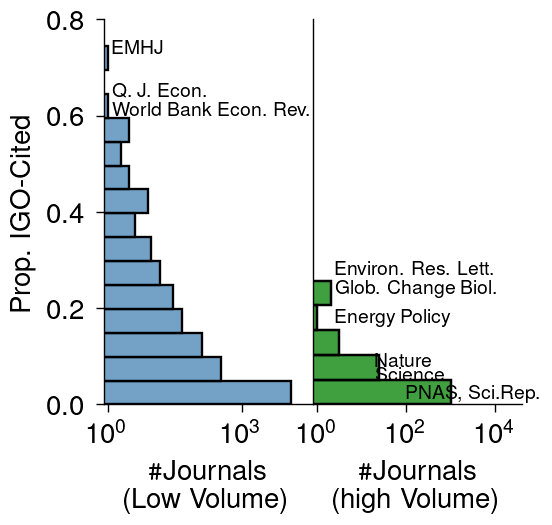

In [37]:

import matplotlib.pyplot as plt

plt.style.use(['science'])

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "axes.spines.right": False,
    "axes.spines.top": False,
})

plt.rcParams["text.latex.preamble"] = r"""
\usepackage{helvet}
\usepackage{sansmath}
\sansmath
\renewcommand{\familydefault}{\sfdefault}
"""
fig, axs = plt.subplots(1, 2, figsize=(2.7, 2.5), sharey=True,
                        gridspec_kw={'width_ratios': [1, 1], 'wspace': 0})

ax = axs[0]
sns.histplot(data=journal.query('num_paper <= 500 and num_paper > 50'),
            y='per', color='#4583B5', binwidth=0.05, kde=False, ax=ax)
ax.set_yticks([0, 0.4, 0.8])
ax.set_ylim([0, 0.8])
ax.set_xscale('log')
ax.set_xlim([0.8, 40000])
ax.set_xticks([1, 1000])
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.set_xlabel(r"\texttt{\#}Journals" + "\n (Low Volume) ")
ax.set_ylabel('Prop. IGO-Cited')
ax.annotate('EMHJ', (1.2, 0.73), fontsize=7)
ax.annotate('Q. J. Econ.', (1.2, 0.64), fontsize=7)
ax.annotate('World Bank Econ. Rev.', (1.2, 0.60), fontsize=7)
ax.tick_params(which='major', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', direction='out', left=False, bottom=True)

ax = axs[1]
sns.histplot(data=journal.query('num_paper > 500'),
            y='per', color='g', binwidth=0.05, kde=False, ax=ax)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax.set_xscale('log')
ax.set_ylim([0, 0.8])
ax.set_xlim([0.8, 40000])
ax.set_xticks([1, 100, 10000])
ax.set_xlabel(r"\texttt{\#}Journals" + "\n (high Volume) ")
ax.set_ylabel('Prop. IGO-cited')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.annotate('Environ. Res. Lett.', (2.5, 0.27), fontsize=7)
ax.annotate('Glob. Change Biol.', (2.5, 0.23), fontsize=7)
ax.annotate('Energy Policy', (2.5, 0.17), fontsize=7)
ax.annotate('Science', (20, 0.05), fontsize=7)
ax.annotate('Nature', (20, 0.08), fontsize=7)
ax.annotate('PNAS, Sci.Rep.', (100, 0.012), fontsize=7)

[x.set_visible(False) for x in ax.get_yticklabels()]
[x.set_visible(False) for x in ax.get_yticklines()]
ax.tick_params(which='major', direction='out', left=False, bottom=True)
ax.tick_params(which='minor', direction='out', left=False, bottom=True)


plt.savefig(f'../output/figures/fig1_c_journal_prop.eps', bbox_inches='tight')
plt.savefig(f'../output/figures/fig1_c_journal_prop.pdf', bbox_inches='tight')
plt.show()

In [38]:

print("=== Low volume journals (top IGO-cited rate) ===")
print(journal.query('num_paper <= 500 and num_paper > 30').sort_values('per').tail(10)[['name', 'num_paper', 'per']])

print("\n=== High volume journals (top IGO-cited rate) ===")
print(journal.query('num_paper >= 500').sort_values('per').tail(10)[['name', 'num_paper', 'per']])

print("\n=== Major journals ===")
print(journal[journal['name'].isin(['Nature', 'Science', 'Scientific Reports', 
                                     'Proceedings of the National Academy of Sciences'])][['name', 'num_paper', 'per']])

=== Low volume journals (top IGO-cited rate) ===
                                             name  num_paper       per
journal                                                               
20246                  Journal of labor economics         32  0.500000
22904            Oxford Review of Economic Policy         62  0.516129
24404                Journal of Political Economy        108  0.518519
19900192023                 Earth System Dynamics         69  0.550725
22524                              Climate Policy        106  0.556604
21255                          Feminist Economics         31  0.580645
14834            Journal of Development Economics        131  0.595420
27365                  World Bank Economic Review         54  0.629630
29431              Quarterly Journal of Economics         40  0.675000
20214        Eastern Mediterranean Health Journal        223  0.744395

=== High volume journals (top IGO-cited rate) ===
                                                

In [33]:
print(f"Output files saved to: ../output/figures")


=== 完了 ===
Output files saved to: ../output/figures


In [23]:
# ========== Table: Country-level comparison ==========

top50 = ['chn', 'usa', 'ind', 'gbr', 'deu', 'jpn', 'ita', 'rus', 'fra', 'can',
         'esp', 'kor', 'aus', 'bra', 'irn', 'tur', 'pol', 'nld', 'idn', 'twn',
         'che', 'mys', 'swe', 'bel', 'prt', 'mex', 'zaf', 'egy', 'dnk', 'cze',
         'sau', 'pak', 'aut', 'isr', 'nor', 'tha', 'grc', 'sgp', 'ukr', 'fin']

top50 = list(country_paper.index[:50])

table = res[res['country'].isin(top50)].pivot(index='country', columns='gr', values=['act', 'est', 'per'])
table = table.loc[top50]

with open('../output/tables/country_papers.tex', 'w') as f:
    f.write("\\begin{tabular}{lccc|c|c|c}\n\\toprule\n")
    f.write("\\textbf{Country} & \\textbf{Act} & \\textbf{Est} & \\textbf{Act/Est} & \\textbf{Act/Est} & \\textbf{Act/Est} & \\textbf{Act/Est} \\\\\n\\midrule\n")
    for c in top50:
        row = table.loc[c]
        f.write(f"{c} & {row[('act','gr0')]:.2f} & {row[('est','gr0')]:.2f} & {row[('per','gr0')]:.2f} & "
                f"{row[('per','gr1')]:.2f} & {row[('per','gr2')]:.2f} & {row[('per','gr3')]:.2f} \\\\\n")
    f.write("\\bottomrule\n\\end{tabular}\n")

print("Saved to ../output/tables/country_papers.tex")

Saved to ../output/tables/country_papers.tex
